In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/starbucks_customer_ordering.csv')
print("Размер:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о типах и пропусках:")
df.info()
print("\nСтатистика числовых столбцов:")
display(df.describe())

Размер: (100000, 20)

Первые 5 строк:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3



Информация о типах и пропусках:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   order_id               100000 non-null  str    
 2   order_date             100000 non-null  str    
 3   order_time             100000 non-null  str    
 4   day_of_week            100000 non-null  str    
 5   order_channel          100000 non-null  str    
 6   store_id               100000 non-null  str    
 7   store_location_type    100000 non-null  str    
 8   region                 100000 non-null  str    
 9   customer_age_group     100000 non-null  str    
 10  customer_gender        100000 non-null  str    
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend    

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,3.741510,1.81077,14.866771,4.546080,3.687530
std,1.697817,1.46280,5.506800,1.550269,1.184123
min,1.000000,0.00000,3.510000,1.000000,1.000000
25%,3.000000,1.00000,10.837500,3.400000,3.000000
50%,4.000000,2.00000,14.170000,4.400000,4.000000
75%,5.000000,3.00000,18.180000,5.500000,5.000000
max,10.000000,8.00000,40.310000,11.200000,5.000000


In [4]:
# Проверка пропусков
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_table = pd.DataFrame({'missing': missing, '%': missing_pct})
print(missing_table[missing_table['missing'] > 0])

Empty DataFrame
Columns: [missing, %]
Index: []


In [5]:
dups = df.duplicated().sum()
print(f"Дубликаты: {dups}")
if dups > 0:
    df = df.drop_duplicates()

Дубликаты: 0


In [8]:
# ----- 2.1 Выбросы -----
# Идентифицируем целевую переменную – предположим, она называется 'total_spent'
target_col = 'total_spent'   # если в датасете другое имя, замените (проверьте: 'Total', 'Amount' и т.п.)
if target_col not in df.columns:
    # поищем похожие названия
    possible_targets = [col for col in df.columns if 'total' in col.lower() or 'spent' in col.lower() or 'amount' in col.lower()]
    if possible_targets:
        target_col = possible_targets[0]
        print(f"Целевая переменная предположительно: {target_col}")
    else:
        raise ValueError("Не удалось определить целевую переменную. Укажите вручную.")

Целевая переменная предположительно: total_spend


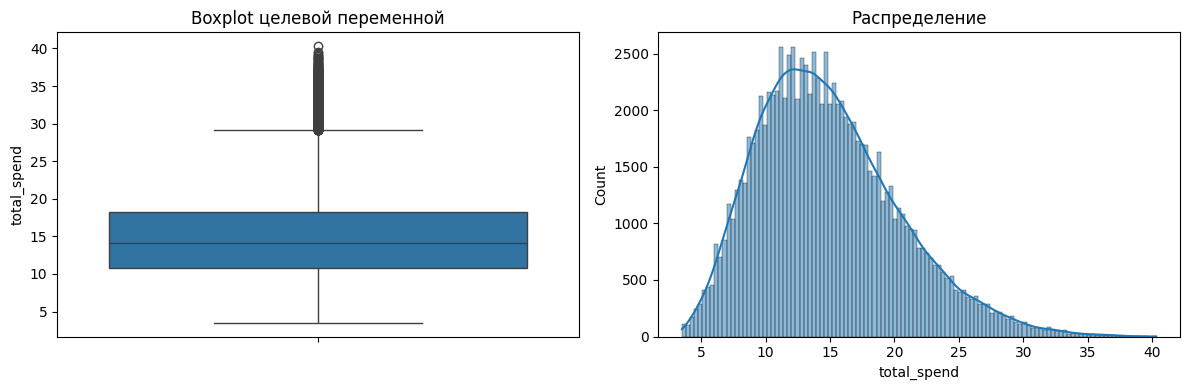

In [9]:
# Визуализация выбросов
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=df[target_col], ax=axes[0])
axes[0].set_title('Boxplot целевой переменной')
sns.histplot(df[target_col], kde=True, ax=axes[1])
axes[1].set_title('Распределение')
plt.tight_layout()
plt.show()

# Применяем логарифмическое преобразование (уменьшает влияние выбросов)
df['total_spent_log'] = np.log1p(df[target_col])

In [14]:
# ----- 2.2 Типы данных -----
# Преобразуем дату и время
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])
if 'order_time' in df.columns:
    df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S', errors='coerce')
    # Если не получилось, можно попробовать автоматически
    if df['order_time'].isnull().any():
        df['order_time'] = pd.to_datetime(df['order_time'], errors='coerce')

# Категориальные признаки переводим в тип category
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype('category')

In [15]:
# ----- 3.1 Извлечение временных признаков -----
if 'order_time' in df.columns:
    # Извлекаем час, минуту, день недели
    df['hour'] = df['order_time'].dt.hour
    df['minute'] = df['order_time'].dt.minute
    df['day_of_week'] = df['order_date'].dt.dayofweek   # если есть order_date
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Категория времени суток
    def time_period(h):
        if 5 <= h < 12: return 'morning'
        elif 12 <= h < 17: return 'afternoon'
        elif 17 <= h < 21: return 'evening'
        else: return 'night'
    df['time_period'] = df['hour'].apply(time_period).astype('category')

In [16]:
# ----- 3.2 Признаки на основе количества товаров и персонализации -----
# Предположим, есть столбцы: 'quantity', 'customization_count', 'item_price'
if 'quantity' in df.columns and 'item_price' in df.columns:
    df['line_total'] = df['quantity'] * df['item_price']
if 'customization_count' in df.columns:
    df['customization_intensity'] = df['customization_count'] / (df['quantity'] + 1e-5)
    df['customization_flag'] = (df['customization_count'] > 0).astype(int)

In [17]:
# ----- 3.3 Агрегированные признаки (на уровне заказа, если есть несколько строк на заказ) -----
# Если датасет уже на уровне заказа – пропускаем. Если на уровне товаров в чеке – сгруппируем.
# Проверим, повторяются ли order_id
if 'order_id' in df.columns:
    if df['order_id'].duplicated().any():
        # Агрегируем: сумма по заказу, количество уникальных товаров и т.д.
        agg = df.groupby('order_id').agg({
            target_col: 'sum',
            'quantity': 'sum',
            'customization_count': 'sum',
            'item_price': 'mean'
        }).rename(columns={target_col: 'order_total'})
        # Теперь работаем с агрегированным датафреймом
        df = agg.reset_index()
        target_col = 'order_total'

# Сохраняем очищенные и расширенные данные
df.to_csv('../data/processed/cleaned_data.csv', index=False)
print("Очищенные данные сохранены в data/processed/cleaned_data.csv")

Очищенные данные сохранены в data/processed/cleaned_data.csv


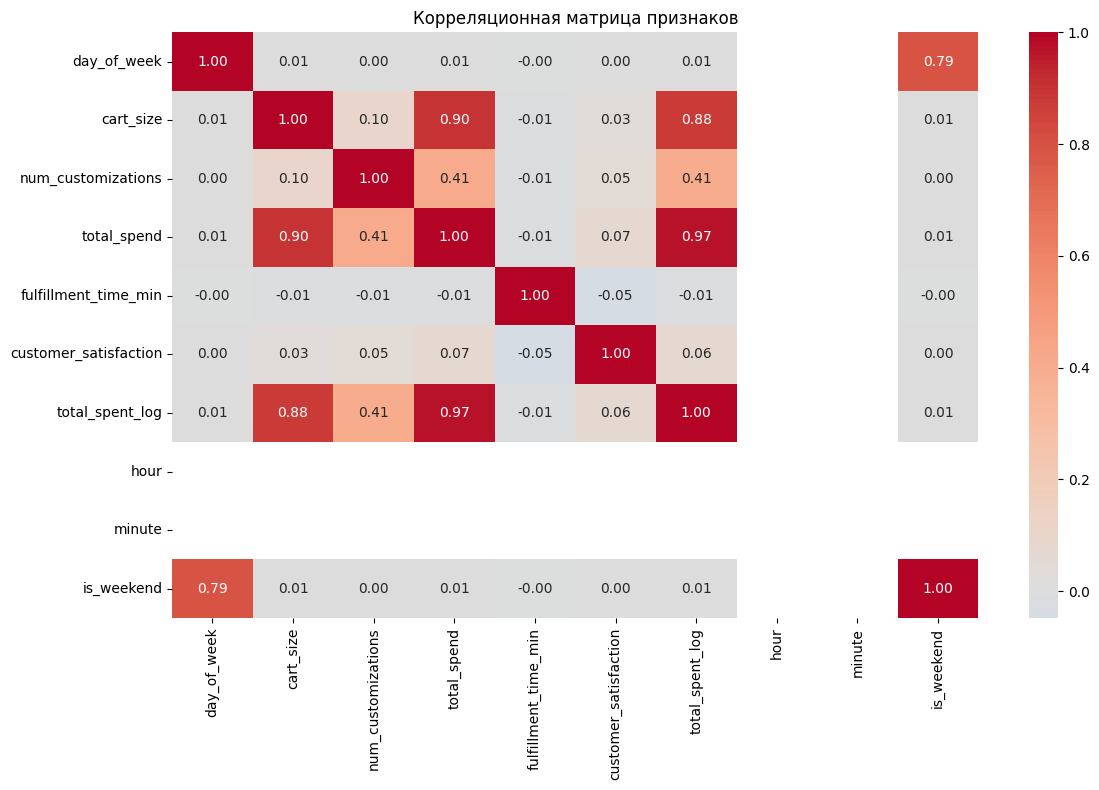

In [20]:
# Корреляционная матрица (только числовые)
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

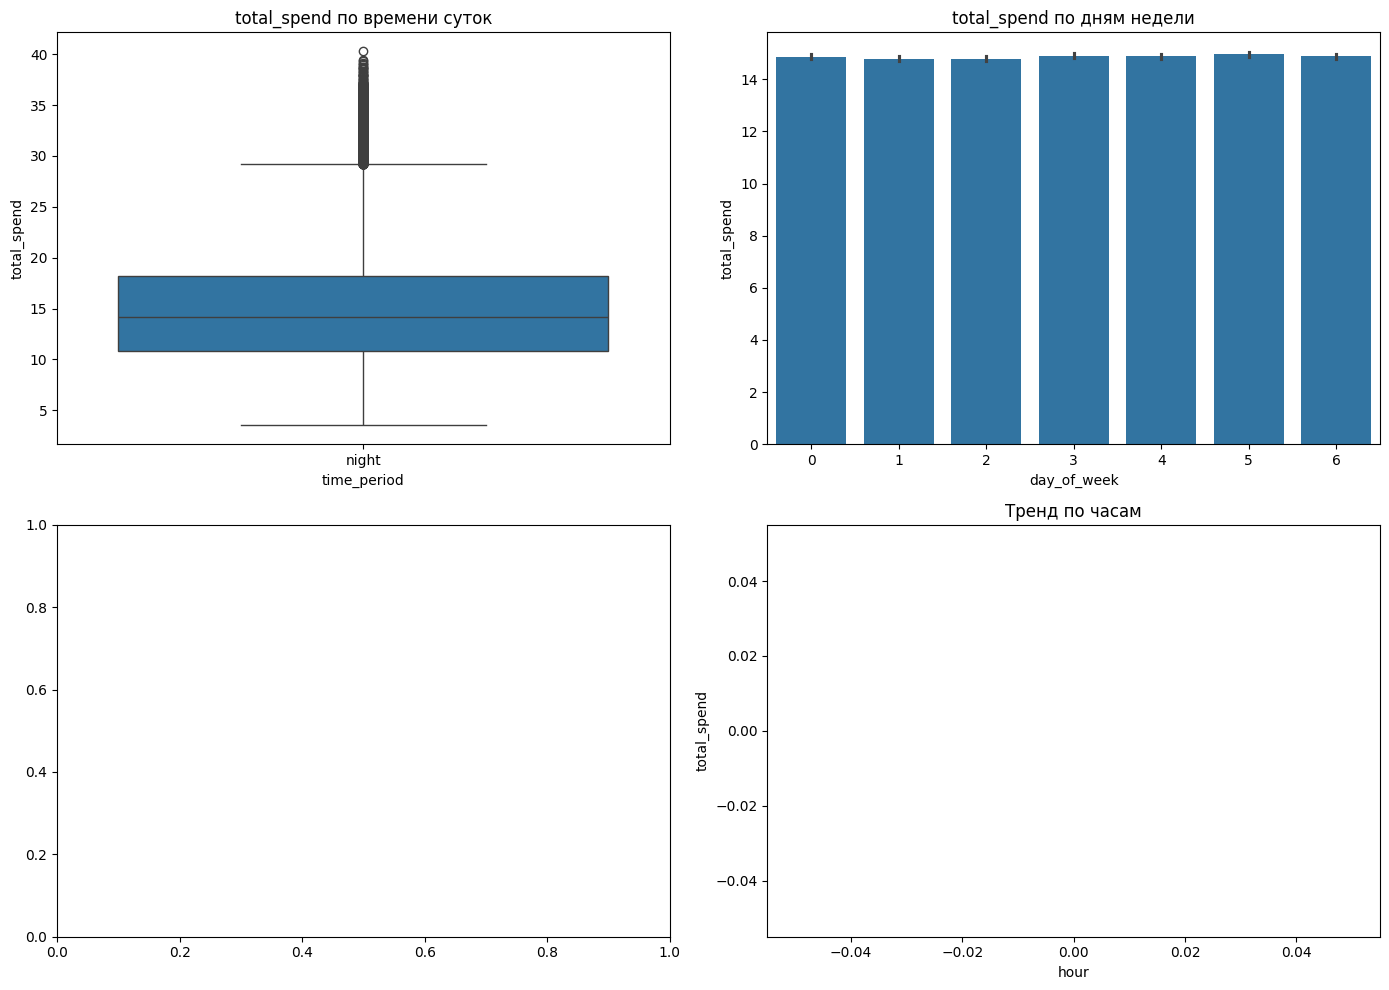

In [ ]:
#ПОМЕНЯТЬ НАЗВАНИЯ СТОЛБЦОВ!!!!!
# Зависимость целевой переменной от ключевых признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# От времени суток
if 'time_period' in df.columns:
    sns.boxplot(data=df, x='time_period', y=target_col, ax=axes[0,0])
    axes[0,0].set_title(f'{target_col} по времени суток')
# От дня недели
if 'day_of_week' in df.columns:
    sns.barplot(data=df, x='day_of_week', y=target_col, ax=axes[0,1])
    axes[0,1].set_title(f'{target_col} по дням недели')
# От количества персонализации
if 'customization_count' in df.columns:
    sns.scatterplot(data=df, x='customization_count', y=target_col, ax=axes[1,0])
    axes[1,0].set_title('Зависимость от количества кастомизаций')
# От часа
if 'hour' in df.columns:
    sns.lineplot(data=df, x='hour', y=target_col, ax=axes[1,1])
    axes[1,1].set_title('Тренд по часам')
plt.tight_layout()
plt.show()